В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [4]:
from process_bank_data import preprocess_bank_data, preprocess_new_data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree, export_text

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [5]:
data = preprocess_bank_data("train.csv")
X_train = data['X_train']
y_train = data['train_targets']
X_val = data['X_val']
y_val = data['val_targets']

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [8]:
def predict_proba_auroc(model, X_train, X_val, y_train, y_val):
    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, train_probs, pos_label=1)
    train_roc_auc = auc(fpr, tpr)
    print('train', train_roc_auc)
    fpr, tpr, thresholds = roc_curve(y_val, val_probs, pos_label=1)
    val_roc_auc = auc(fpr, tpr)
    print('val', val_roc_auc)

In [13]:
predict_proba_auroc(knn, X_train, X_val, y_train, y_val)

train 0.9559428457733543
val 0.852585568283147


Модель досить непогана, але спостерігається overfitting. Модель не дуже гіперболізує на валідаційних даних

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [17]:
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [18]:
knn_best = knn_gs.best_estimator_
predict_proba_auroc(knn_best, X_train, X_val, y_train, y_val)

train 0.9407278147861952
val 0.8808731737430551


Модель показала себе трошки краще на валідаційних даних ніж модель в попередньому завданні. Але вона поки що гірша ніж модель з попереднього домашнього

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [21]:
%%time
model = DecisionTreeClassifier(random_state=42)
params_dtc = {'max_depth': np.arange(1, 20, 2),
             'max_leaf_nodes': np.arange(2, 10)}
dtc_gs = GridSearchCV(model, params_dtc, cv=3, scoring='roc_auc')
dtc_gs.fit(X_train, y_train)

CPU times: total: 2.5 s
Wall time: 3.01 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='roc_auc')

In [22]:
dt_best = dtc_gs.best_estimator_
predict_proba_auroc(dt_best, X_train, X_val, y_train, y_val)

train 0.9001138615074584
val 0.898395980519926


Ця модель гірша ніж та, що я знайшла вручну, тому що в мене max_depth було 6, а тут ми йшли з кроком 2, і шість навіть немає в нашому списку варіантів для параметрів

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [25]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [55]:
%%time
dtc_rs = RandomizedSearchCV(model, params_dt, n_iter=40, scoring='roc_auc', cv=3, random_state = 42)
dtc_rs.fit(X_train, y_train)

CPU times: total: 422 ms
Wall time: 1.03 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [57]:
dt_random_search_best = dtc_rs.best_estimator_
predict_proba_auroc(dt_random_search_best, X_train, X_val, y_train, y_val)

train 0.9169275635848141
val 0.9166204815145071


Ця модель суттєво краща і пошук відбувався в два рази швидше

In [53]:
dtc_rs.best_params_

{'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': 14,
 'max_features': None,
 'max_depth': 16,
 'criterion': 'entropy'}

In [39]:
dtc_gs.best_params_

{'max_depth': 5, 'max_leaf_nodes': 9}

Хотіла написати, що рандом пошук мені знайшов рівно ті параметри які я вручну шукала, але перезапустила ще раз і він вже знайшов зовсім інші параметри. Випадковий пошук може бути кращій і його моделі точніші, але він не стабільний.
Потім таки зафіксувала random_state, тепер результат стабільний, але гірший ніж був до того :)
Але в будь якому випадку, результати швидші і все ж таки показники моделі вищі ніж після Grid Search

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [41]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = dt_random_search_best.predict_proba(preprocess_new_data(test_raw_df, data['input_cols'], data['numeric_cols'], data['categorical_cols'], data['scaler'], data['encoder']))[:, 1]
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.237911
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.012115
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.145078
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.637597
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.082171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.012115
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.012115
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.012115
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.039301


In [43]:
submission = pd.read_csv('sample_submission.csv')
submission['Exited'] = test_raw_df['id'].map(test_raw_df.set_index('id')['Exited'])
submission.to_csv('submission_log_reg.csv', index=False)

Модель вийшла трохи краща ніж в минулому завданні, але все ще трохи гірша ніж логістична регресія
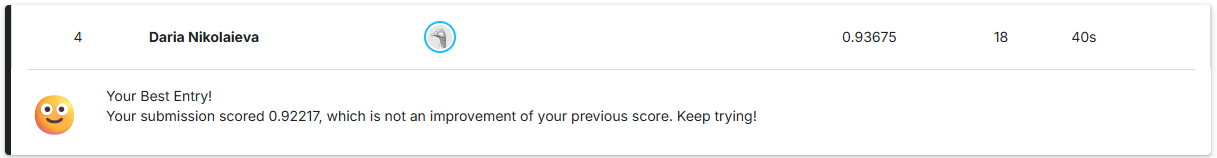